testing the difference between:
1) open porosity (Figure S7 in Mitchell et al. 2013) and closed porosity (Figure 3 in Mitchell et al. 2015) gas age distributions on firn air smoothing and power spectra.
2) gamma distribution vs. log-logistic distribution for the closed porosity gas age distribution.
3) (future) actual firn filter vs. what I'm using

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq
from pathlib import Path

from methane_noise_forcing.core import FirnFilter

In [2]:
# define function for plotting the Fourier transform of the filter
def plot_filter_fourier_transform(ax, firn_filter: FirnFilter, **kwargs):
    """Plot the Fourier transform of a FirnFilter."""
    freq = fftfreq(len(firn_filter.kernel), d=firn_filter.dt)
    fourier_transform = np.abs(fft(firn_filter.kernel))
    ax.loglog(freq[freq > 0], fourier_transform[freq > 0], **kwargs)

# firn filters

In [3]:
# universal parameters
t_max = 300  # maximum time for the kernel in years
dt = 0.5  # time step for the kernel in years

## gamma firn filters

In [4]:
## create filters for open and closed porosities with gamma distribution
# open porosity filter
mode_open = 25  # years
fwhm_open = 22  # years
skew_open = 0.65
firn_filter_gamma_open = FirnFilter.fit_gamma(
    mode=mode_open, fwhm=fwhm_open, skew=skew_open, t_max=t_max, dt=dt
)

# closed porosity filter
mode_closed = 80  # years
fwhm_closed = 26  # years
skew_closed = 0.65
firn_filter_gamma_closed = FirnFilter.fit_gamma(
    mode=mode_closed, fwhm=fwhm_closed, skew=skew_closed, t_max=t_max, dt=dt
)

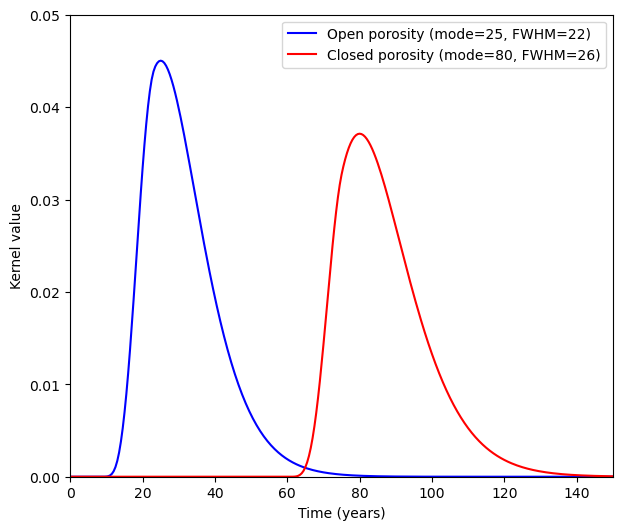

In [5]:
## plot firn filters against each other
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(
    np.arange(0, t_max + dt, dt),
    firn_filter_gamma_open.kernel,
    label=f"Open porosity (mode={mode_open}, FWHM={fwhm_open})",
    color="blue",
)
ax.plot(
    np.arange(0, t_max + dt, dt),
    firn_filter_gamma_closed.kernel,
    label=f"Closed porosity (mode={mode_closed}, FWHM={fwhm_closed})",
    color="red",
)

ax.set_xlabel("Time (years)")
ax.set_ylabel("Kernel value")
ax.set_xlim(0, 150)
ax.set_ylim(0, 0.05)
ax.legend()

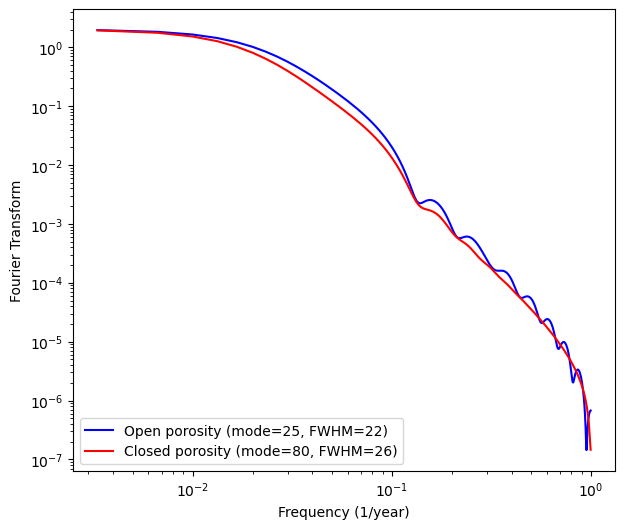

In [6]:
## plot fourier transforms of the filters
fig, ax = plt.subplots(figsize=(7, 6))
plot_filter_fourier_transform(
    ax,
    firn_filter_gamma_open,
    label=f"Open porosity (mode={mode_open}, FWHM={fwhm_open})",
    color="blue",
)
plot_filter_fourier_transform(
    ax,
    firn_filter_gamma_closed,
    label=f"Closed porosity (mode={mode_closed}, FWHM={fwhm_closed})",
    color="red",
)

ax.set_xlabel("Frequency (1/year)")
ax.set_ylabel("Fourier Transform")
ax.legend()

## log-logistic firn filters

In [7]:
## create filters for open and closed porosities with log-logistic distribution
# open porosity filter
mode_open = 25  # years
fwhm_open = 22  # years
skew_open = 0.65
firn_filter_log_logistic_open = FirnFilter.fit_log_logistic(
    mode=mode_open, fwhm=fwhm_open, skew=skew_open, t_max=t_max, dt=dt
)

# closed porosity filter
mode_closed = 80  # years
fwhm_closed = 26  # years
skew_closed = 0.65
firn_filter_log_logistic_closed = FirnFilter.fit_log_logistic(
    mode=mode_closed, fwhm=fwhm_closed, skew=skew_closed, t_max=t_max, dt=dt
)

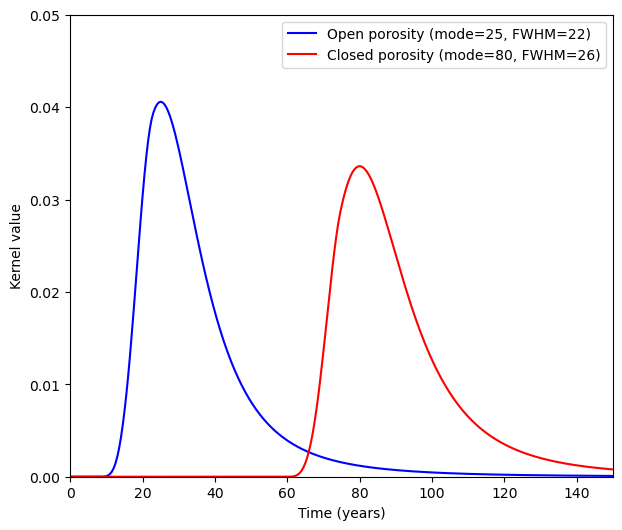

In [8]:
## plot firn filters against each other
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(
    np.arange(0, t_max + dt, dt),
    firn_filter_log_logistic_open.kernel,
    label=f"Open porosity (mode={mode_open}, FWHM={fwhm_open})",
    color="blue",
)
ax.plot(
    np.arange(0, t_max + dt, dt),
    firn_filter_log_logistic_closed.kernel,
    label=f"Closed porosity (mode={mode_closed}, FWHM={fwhm_closed})",
    color="red",
)

ax.set_xlabel("Time (years)")
ax.set_ylabel("Kernel value")
ax.set_xlim(0, 150)
ax.set_ylim(0, 0.05)
ax.legend()

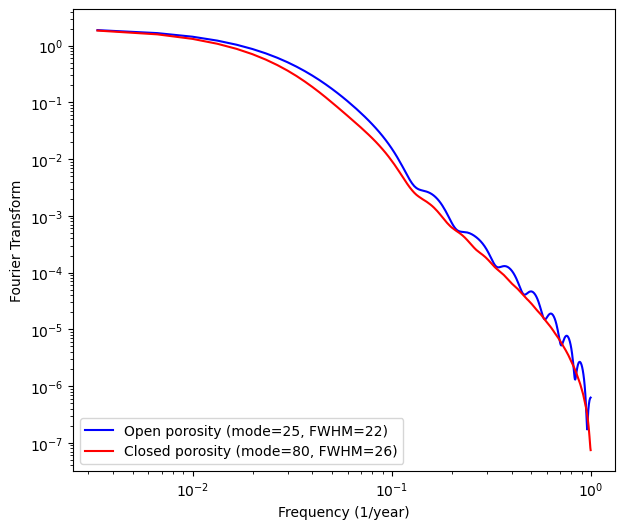

In [9]:
## plot fourier transforms of the filters
fig, ax = plt.subplots(figsize=(7, 6))
plot_filter_fourier_transform(
    ax,
    firn_filter_log_logistic_open,
    label=f"Open porosity (mode={mode_open}, FWHM={fwhm_open})",
    color="blue",
)
plot_filter_fourier_transform(
    ax,
    firn_filter_log_logistic_closed,
    label=f"Closed porosity (mode={mode_closed}, FWHM={fwhm_closed})",
    color="red",
)

ax.set_xlabel("Frequency (1/year)")
ax.set_ylabel("Fourier Transform")

ax.legend()

clear artifacts sub-10 year periods, but that will be okay for our purposes. These artifacts are either due to not enough taper on the edge of the log-logistic function or on the edge of the kernel itself.
The filters are very similar, though. I suspect this is because they don't actually look all that different other than their offset.

## compare closed porosity gamma vs. log-logistic

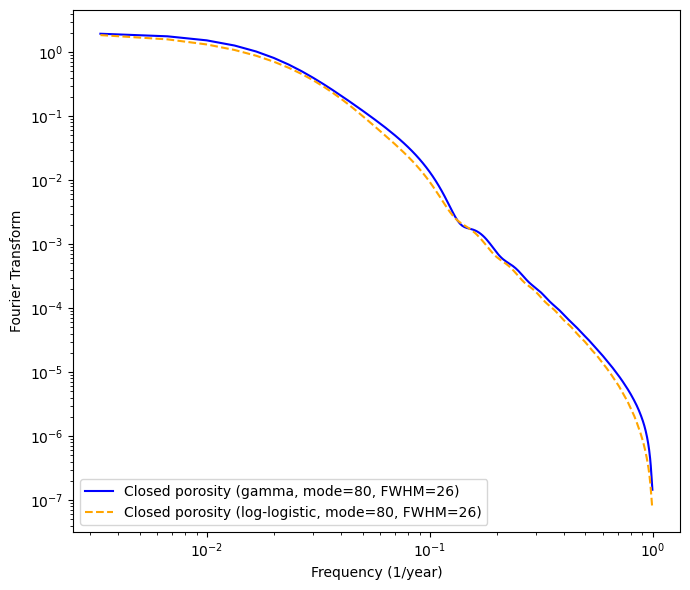

In [10]:
## plot fourier transforms of the gamma vs. log-logistic filters
fig, ax = plt.subplots(figsize=(7, 6))
plot_filter_fourier_transform(
    ax,
    firn_filter_gamma_closed,
    label=f"Closed porosity (gamma, mode={mode_closed}, FWHM={fwhm_closed})",
    color="blue",
)
plot_filter_fourier_transform(
    ax,
    firn_filter_log_logistic_closed,
    label=f"Closed porosity (log-logistic, mode={mode_closed}, FWHM={fwhm_closed})",
    color="orange",
    linestyle="--",
)

ax.set_xlabel("Frequency (1/year)")
ax.set_ylabel("Fourier Transform")
ax.legend()
plt.tight_layout()

The filters above are basically identical

# load firn filters from file

In [11]:
# load only neem for example
path_neem = Path(
    "/Users/ericm/Documents/Research/methane_noise_forcing/data/firn_filters/firn_filter_neem.csv"
)

firn_filter_neem = FirnFilter.from_firn_model(path=path_neem)

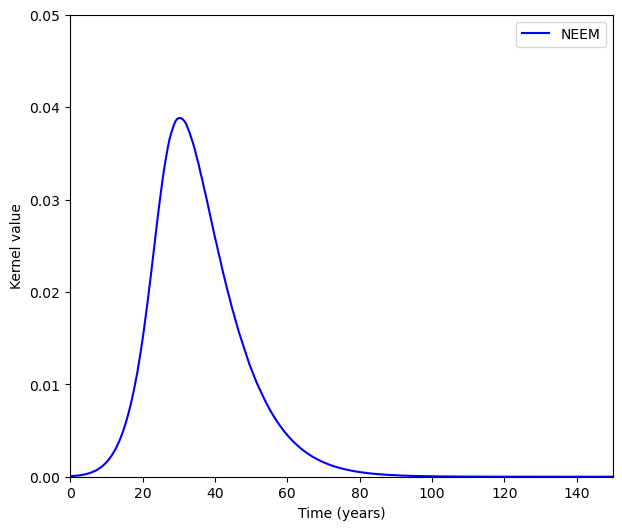

In [12]:
## plot firn
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(
    np.arange(0, len(firn_filter_neem.kernel) * dt, dt),
    firn_filter_neem.kernel,
    label=f"NEEM",
    color="blue",
)

ax.set_xlabel("Time (years)")
ax.set_ylabel("Kernel value")
ax.set_xlim(0, 150)
ax.set_ylim(0, 0.05)
ax.legend()

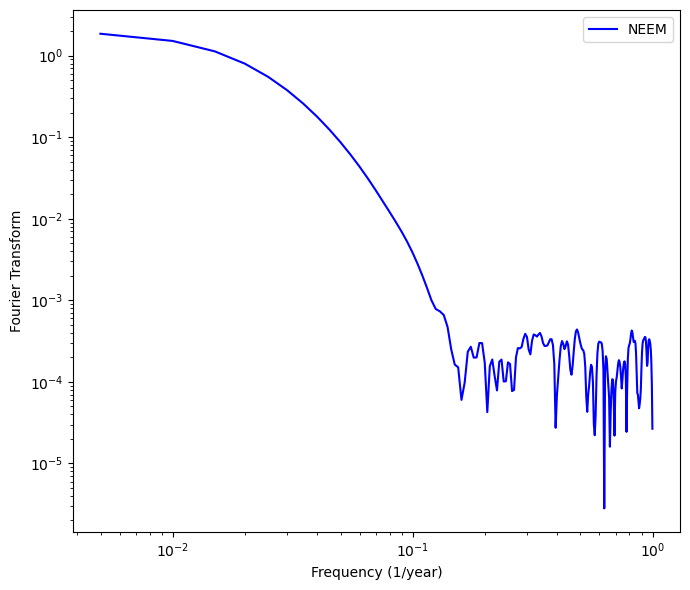

In [13]:
## plot fourier transforms of the gamma vs. log-logistic filters
fig, ax = plt.subplots(figsize=(7, 6))
plot_filter_fourier_transform(
    ax,
    firn_filter_neem,
    label="NEEM",
    color="blue",
)

ax.set_xlabel("Frequency (1/year)")
ax.set_ylabel("Fourier Transform")
ax.legend()
plt.tight_layout()